# Run test on SZA Singing Dataset

In [6]:
!pip install pandas seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [4]:
import os
import requests
import pandas as pd
from pathlib import Path
import json

# ==========================================================
# CẤU HÌNH
# ==========================================================
# Đường dẫn tới thư mục chứa dataset.
# CẦN ĐIỀU CHỈNH CHÍNH XÁC THEO CẤU TRÚC THƯ MỤC CỦA BẠN!
DATASET_PATH = Path('./SZA_Singing')
API_URL = 'http://0.0.0.0:8000/file/process'
OUTPUT_CSV_FILE = 'analysis_results.csv'
SR_REFERENCE = 16000 # Tần số lấy mẫu mặc định của hệ thống lọc


def process_file_via_api(file_path: Path) -> dict:
    """
    Gửi file WAV đến API và xử lý phản hồi JSON.
    """
    file_name = file_path.name
    print(f"--- Processing: {file_name} ---")

    # 1. Khởi tạo template với các giá trị mặc định (None/NaN)
    # Điều này đảm bảo tất cả các dictionary đều có cùng các key
    row = {
        'song_name': file_name,
        'file_size_kb': None,
        'date_process': None,

        'wiener_improvement_%': None,
        'wiener_performance': None,
        'wiener_time_s': None,

        'mmse_improvement_%': None,
        'mmse_performance': None,
        'mmse_time_s': None,

        'best_improvement_%': None,
        'best_performance': None,
        'best_time_s': None,
        'error': None # Key 'error' luôn phải tồn tại
    }

    # FastAPI nhận input dưới dạng 'multipart/form-data'
    files = {
        'file': (file_name, open(file_path, 'rb'), 'audio/wav')
    }

    try:
        response = requests.post(API_URL, headers={'accept': 'application/json'}, files=files)
        response.raise_for_status() # Báo lỗi nếu status code không phải 2xx

        data = response.json()

        # 2. Trích xuất dữ liệu thành công
        row.update({
            'file_size_kb': data['file_size_kb'],
            'date_process': data['date_process'],

            # Wiener Smooth
            'wiener_improvement_%': data['comparison']['wiener_smooth']['improvement_percent'],
            'wiener_performance': data['comparison']['wiener_smooth']['performance'],
            'wiener_time_s': data['comparison']['wiener_smooth']['time_seconds'],

            # MMSE-LSA
            'mmse_improvement_%': data['comparison']['mmse_lsa']['improvement_percent'],
            'mmse_performance': data['comparison']['mmse_lsa']['performance'],
            'mmse_time_s': data['comparison']['mmse_lsa']['time_seconds'],

            # Best
            'best_improvement_%': data['comparison']['best']['improvement_percent'],
            'best_performance': data['comparison']['best']['performance'],
            'best_time_s': data['comparison']['best']['time_seconds'],
        })
        print(f"    -> SUCCESS. Best Improvement: {row['best_improvement_%']}%")

    except requests.exceptions.RequestException as e:
        row['error'] = f"API Request Failed: {e}"
        print(f"    -> ERROR calling API: {e}")
    except json.JSONDecodeError:
        row['error'] = f"Invalid JSON response: {response.text[:100]}..."
        print(f"    -> ERROR: Invalid JSON response.")
    except Exception as e:
        row['error'] = f"Data Parsing Error: {e}"
        print(f"    -> ERROR parsing data: {e}")

    return row

# ==========================================================
# CHẠY QUÁ TRÌNH PHÂN TÍCH
# ==========================================================
if __name__ == '__main__':

    if not DATASET_PATH.is_dir():
        print(f"ERROR: Dataset directory not found at {DATASET_PATH.resolve()}")
    else:
        # 1. Tìm tất cả các file .wav
        wav_files = list(DATASET_PATH.glob('*.wav'))
        if not wav_files:
            print(f"No WAV files found in {DATASET_PATH.resolve()}")
        else:
            print(f"Found {len(wav_files)} files to process.")

            # 2. Xử lý từng file
            all_results = []
            for file_path in wav_files:
                result = process_file_via_api(file_path)
                all_results.append(result)

            # 3. Tạo DataFrame và lưu CSV
            df = pd.DataFrame(all_results)

            # Xử lý các dòng bị lỗi trước khi lưu (Lỗi KeyError: 'error' đã được sửa)
            error_rows = df[df['error'].notna()]
            if not error_rows.empty:
                print(f"\nWARNING: {len(error_rows)} files failed to process. Check 'error_rows.csv'.")
                # Chỉ chọn các cột liên quan đến lỗi
                error_cols = ['song_name', 'error', 'date_process']
                error_rows[error_cols].to_csv('error_rows.csv', index=False)

            # Chọn các cột số liệu chính để lưu vào file cuối cùng
            # Bỏ cột 'error' khỏi DataFrame chính
            df_final = df.drop(columns=['error'], errors='ignore')

            df_final.to_csv(OUTPUT_CSV_FILE, index=False)
            print("-" * 40)
            print(f"DONE. Results saved to {OUTPUT_CSV_FILE}")
            print(f"Sample of results:\n{df_final.head()}")

Found 135 files to process.
--- Processing: 3_SZA__Love_Galore_6.wav ---
    -> SUCCESS. Best Improvement: 16.7%
--- Processing: 14_SZA__Anything_Filtered_Acapella_Vocals_4.wav ---
    -> SUCCESS. Best Improvement: 9.35%
--- Processing: 10_SZA__Normal_Girl_Filtered_Acapella_Vocals_5.wav ---
    -> SUCCESS. Best Improvement: 15.13%
--- Processing: 10_SZA__Normal_Girl_Filtered_Acapella_Vocals_4.wav ---
    -> SUCCESS. Best Improvement: 12.62%
--- Processing: 14_SZA__Anything_Filtered_Acapella_Vocals_5.wav ---
    -> SUCCESS. Best Improvement: 7.85%
--- Processing: 11_SZA__Kill_Bill_Vocals_Audio_Vocals_0.wav ---
    -> SUCCESS. Best Improvement: 3.12%
--- Processing: 3_SZA__Love_Galore_5.wav ---
    -> SUCCESS. Best Improvement: 13.92%
--- Processing: 14_SZA__Anything_Filtered_Acapella_Vocals_7.wav ---
    -> SUCCESS. Best Improvement: 8.18%
--- Processing: 10_SZA__Normal_Girl_Filtered_Acapella_Vocals_6.wav ---
    -> SUCCESS. Best Improvement: 7.47%
--- Processing: 10_SZA__Normal_Girl_Fi

# Analysis Result


Đã tải 135 kết quả phân tích.
----------------------------------------
Tóm tắt Hiệu suất Trung bình:
                    wiener_improvement_%  mmse_improvement_%  wiener_performance  mmse_performance  wiener_time_s  mmse_time_s  best_improvement_%
Giá trị Trung Bình              7.596296           10.186815            0.786074          0.798519       0.070978     0.133126            10.34437
----------------------------------------

--- THỐNG KÊ CẢI THIỆN ÂM (Tín hiệu tệ hơn) ---
Wiener Smooth: 17/135 file (12.59%)
MMSE-LSA: 9/135 file (6.67%)
----------------------------------------


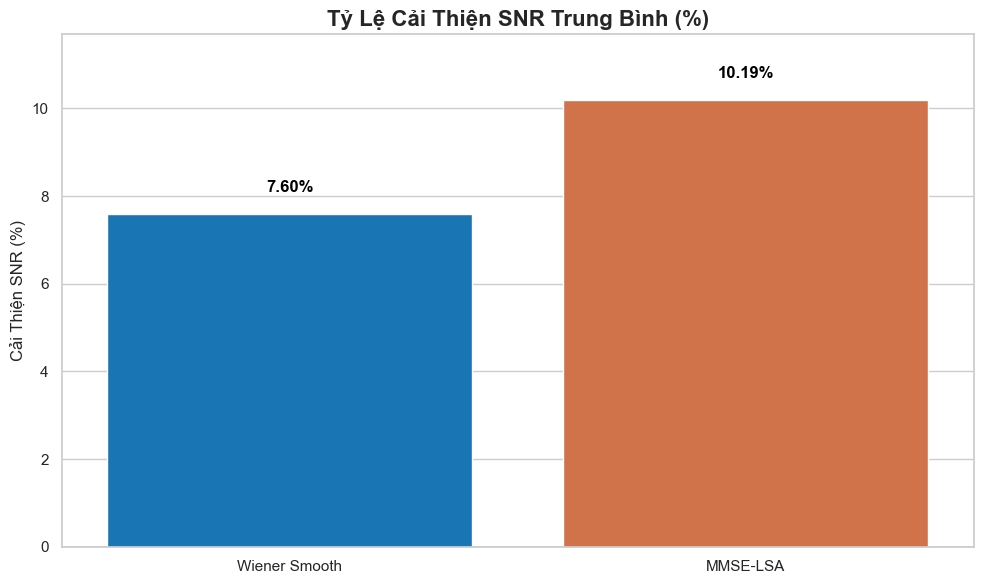

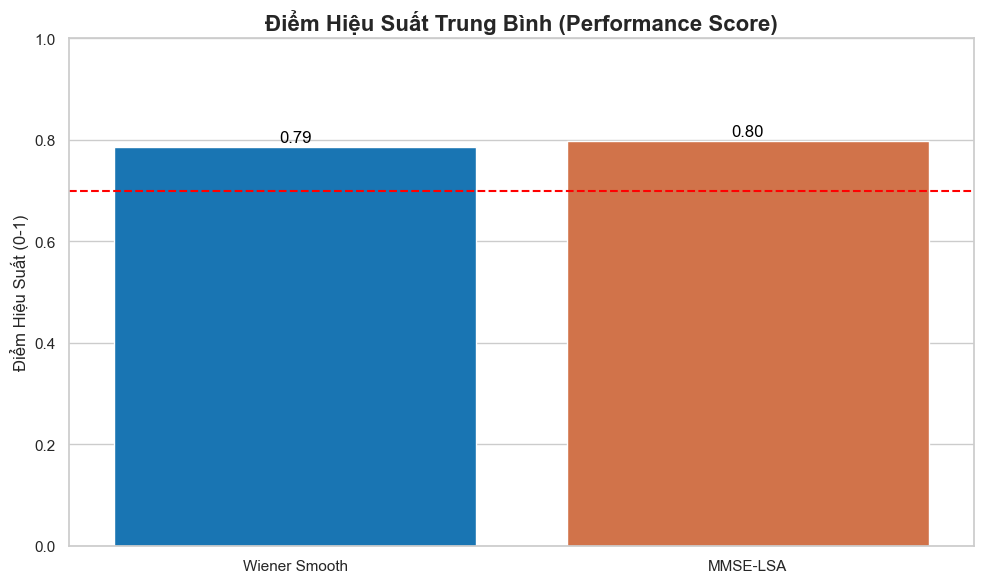

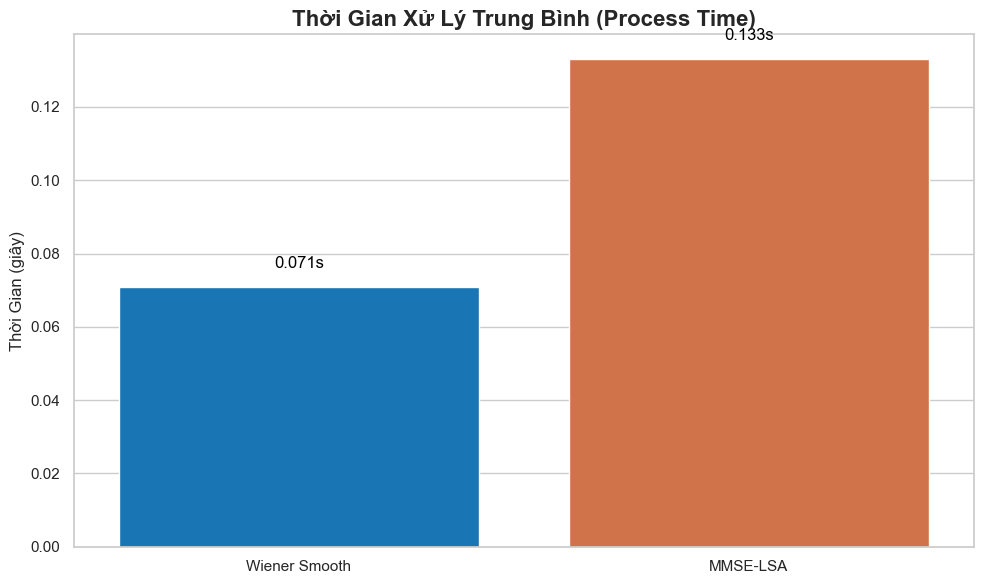

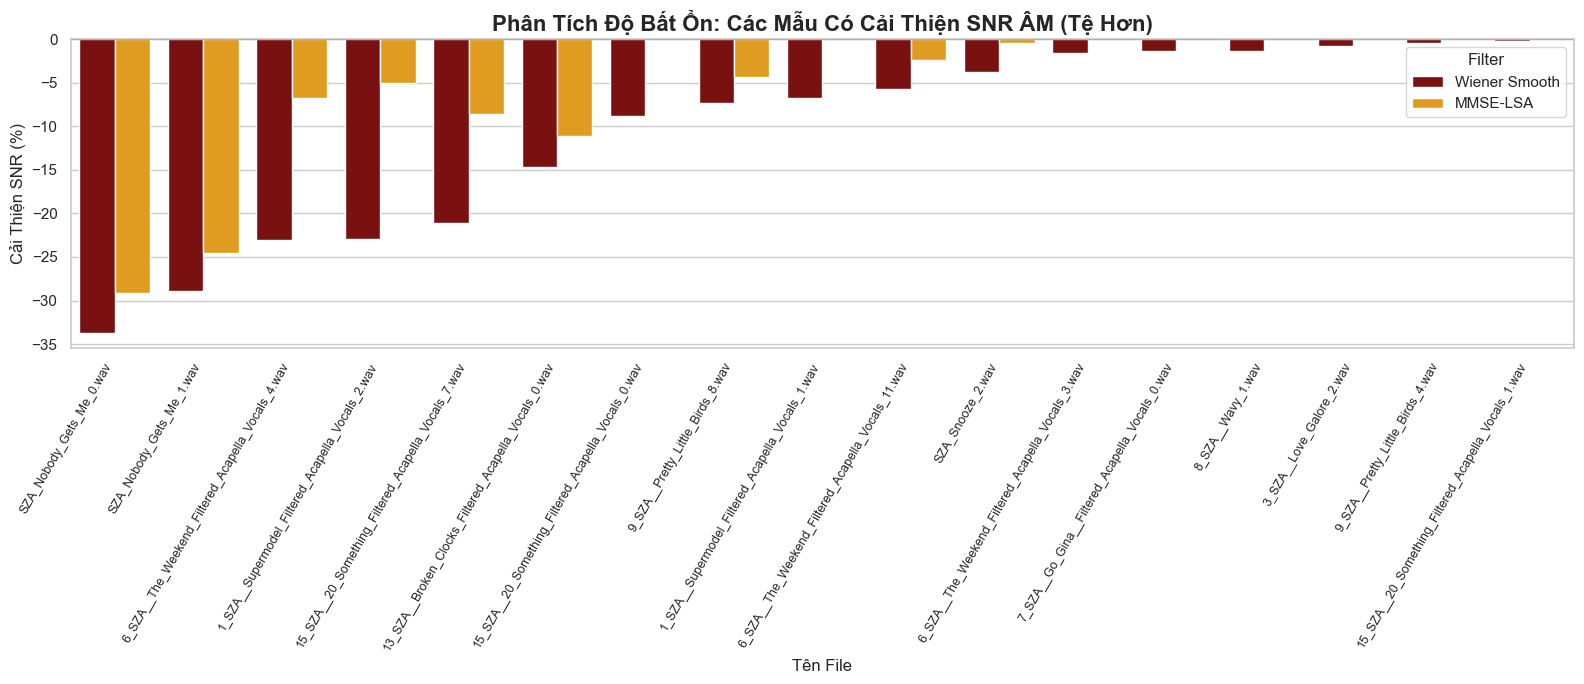

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================================
# CẤU HÌNH PHÂN TÍCH
# ==========================================================
INPUT_CSV_FILE = 'analysis_results.csv'
# Đặt theme cho đồ thị đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)

# Định nghĩa Palette sử dụng tên filter đã làm sạch
FILTERS_PALETTE = {
    'Wiener Smooth': '#007ACC',
    'MMSE-LSA': '#E86A33'
}


def calculate_negative_improvement_stats(df: pd.DataFrame) -> dict:
    """Tính tỷ lệ phần trăm các file mà bộ lọc làm tín hiệu tệ hơn (Cải thiện âm)."""

    total = len(df)

    wiener_neg = (df['wiener_improvement_%'] < 0).sum()
    mmse_neg = (df['mmse_improvement_%'] < 0).sum()

    return {
        'wiener_negative_count': wiener_neg,
        'mmse_negative_count': mmse_neg,
        'wiener_negative_percent': round((wiener_neg / total) * 100, 2),
        'mmse_negative_percent': round((mmse_neg / total) * 100, 2),
    }


def plot_aggregated_results(df_summary: pd.DataFrame, stats: dict):
    """
    Vẽ biểu đồ Barplot tổng hợp (Aggregate) so sánh các chỉ số trung bình
    trên toàn bộ dataset, có tính đến giá trị âm.
    """

    # Lấy dữ liệu trung bình từ df_summary (chỉ có 1 hàng)
    data = df_summary.iloc[0].to_dict()

    # --- 1. CHUẨN BỊ DATAFRAME TỔNG HỢP ---
    df_plot = pd.DataFrame({
        'Filter': ['Wiener Smooth', 'MMSE-LSA'],
        'Improvement': [data['wiener_improvement_%'], data['mmse_improvement_%']],
        'Performance': [data['wiener_performance'], data['mmse_performance']],
        'Time': [data['wiener_time_s'], data['mmse_time_s']],
    })


    # --- 2. VẼ BIỂU ĐỒ 1: CẢI THIỆN SNR TRUNG BÌNH ---
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_plot,
        x='Filter',
        y='Improvement',
        palette=FILTERS_PALETTE,
        hue='Filter',
        legend=False
    )

    # Tính toán giới hạn trục Y
    min_val = df_plot['Improvement'].min()
    y_min = min(0, min_val - 2) # Trục Y phải hiển thị ít nhất -2 hoặc giá trị nhỏ nhất
    plt.ylim(y_min, df_plot['Improvement'].max() + 1.5)

    # Thêm nhãn giá trị trung bình trên đỉnh mỗi cột
    for index, row in df_plot.iterrows():
        # Điều chỉnh vị trí nhãn
        y_text = row['Improvement']
        if y_text >= 0:
            y_pos = y_text + 0.5
            color = 'black'
        else:
            y_pos = y_text - 1.0
            color = 'red'

        plt.text(index, y_pos,
                 f"{y_text:.2f}%",
                 color=color, ha="center", fontsize=12, fontweight='bold')

    # Thêm đường tham chiếu 0
    plt.axhline(0, color='gray', linestyle='-', linewidth=1)

    plt.title('Tỷ Lệ Cải Thiện SNR Trung Bình (%)', fontsize=16, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Cải Thiện SNR (%)', fontsize=12)
    plt.tight_layout()
    plt.show()


    # --- 3. VẼ BIỂU ĐỒ 2: ĐIỂM HIỆU SUẤT TRUNG BÌNH ---
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_plot,
        x='Filter',
        y='Performance',
        palette=FILTERS_PALETTE,
        hue='Filter',
        legend=False
    )

    # Thêm đường tham chiếu cho điểm 0.7
    plt.axhline(0.7, color='red', linestyle='--', linewidth=1.5, label='Điểm Chấp Nhận (0.7)')

    # Thêm nhãn giá trị trung bình trên đỉnh mỗi cột
    for index, row in df_plot.iterrows():
        plt.text(index, row['Performance'] + 0.01,
                 f"{row['Performance']:.2f}",
                 color='black', ha="center", fontsize=12)

    plt.title('Điểm Hiệu Suất Trung Bình (Performance Score)', fontsize=16, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Điểm Hiệu Suất (0-1)', fontsize=12)
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()


    # --- 4. VẼ BIỂU ĐỒ 3: THỜI GIAN XỬ LÝ TRUNG BÌNH (Tùy chọn) ---
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_plot,
        x='Filter',
        y='Time',
        palette=FILTERS_PALETTE,
        hue='Filter',
        legend=False
    )

    # Thêm nhãn giá trị trung bình trên đỉnh mỗi cột
    for index, row in df_plot.iterrows():
        plt.text(index, row['Time'] + 0.005,
                 f"{row['Time']:.3f}s",
                 color='black', ha="center", fontsize=12)

    plt.title('Thời Gian Xử Lý Trung Bình (Process Time)', fontsize=16, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Thời Gian (giây)', fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_negative_improvement_samples(df: pd.DataFrame):
    """
    Tạo biểu đồ chỉ chứa các mẫu có cải thiện SNR là số âm (làm tệ hơn).
    Sử dụng scatter plot hoặc bar plot với màu đỏ.
    """
    # 1. Lọc các mẫu có giá trị cải thiện âm (cho ít nhất 1 filter)
    df_negative = df[
        (df['wiener_improvement_%'] < 0) | (df['mmse_improvement_%'] < 0)
    ].copy()

    if df_negative.empty:
        print("\n--- Biểu đồ Cải thiện Âm: Không có mẫu nào có SNR < 0 ---")
        return

    # 2. Chuẩn bị DataFrame cho biểu đồ (Long format)
    df_plot = df_negative.melt(
        id_vars='song_name',
        value_vars=['wiener_improvement_%', 'mmse_improvement_%'],
        var_name='Filter_Metric',
        value_name='SNR Improvement (%)'
    )

    # Lọc chỉ lấy những giá trị âm
    df_plot = df_plot[df_plot['SNR Improvement (%)'] < 0]

    # Clean tên Filter
    df_plot['Filter'] = df_plot['Filter_Metric'].apply(
        lambda x: 'Wiener Smooth' if 'wiener' in x else 'MMSE-LSA'
    )

    # Sắp xếp theo mức độ giảm SNR
    df_plot = df_plot.sort_values(by='SNR Improvement (%)', ascending=True)

    # 3. VẼ BIỂU ĐỒ BARPLOT CẢI THIỆN ÂM
    plt.figure(figsize=(16, 7))
    sns.barplot(
        data=df_plot,
        x='song_name',
        y='SNR Improvement (%)',
        hue='Filter',
        palette={'Wiener Smooth': 'darkred', 'MMSE-LSA': 'orange'}, # Dùng màu tương phản
    )

    # Thêm đường tham chiếu 0
    plt.axhline(0, color='black', linestyle='-', linewidth=1.5)

    plt.title('Phân Tích Độ Bất Ổn: Các Mẫu Có Cải Thiện SNR ÂM (Tệ Hơn)', fontsize=16, fontweight='bold')
    plt.xlabel('Tên File', fontsize=12)
    plt.ylabel('Cải Thiện SNR (%)', fontsize=12)

    # Đảm bảo tên file không bị chồng lên nhau
    plt.xticks(rotation=60, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()


def run_analysis():
    """Hàm chính để đọc, chuẩn bị và vẽ đồ thị phân tích."""
    try:
        # Đọc file CSV đã tạo từ Cell 1
        df = pd.read_csv(INPUT_CSV_FILE)

        if df.empty:
            print(f"Lỗi: File {INPUT_CSV_FILE} rỗng hoặc không có dữ liệu.")
            return

        print(f"Đã tải {len(df)} kết quả phân tích.")
        print("-" * 40)

        # 1. Tính toán Tóm tắt Trung bình (Mean)
        df_summary = df[['wiener_improvement_%', 'mmse_improvement_%',
                         'wiener_performance', 'mmse_performance',
                         'wiener_time_s', 'mmse_time_s',
                         'best_improvement_%']].mean().to_frame(name='Giá trị Trung Bình').T

        # 2. Tính toán thống kê giá trị âm
        negative_stats = calculate_negative_improvement_stats(df)

        print("Tóm tắt Hiệu suất Trung bình:")
        print(df_summary.to_string())
        print("-" * 40)

        print("\n--- THỐNG KÊ CẢI THIỆN ÂM (Tín hiệu tệ hơn) ---")
        print(f"Wiener Smooth: {negative_stats['wiener_negative_count']}/{len(df)} file ({negative_stats['wiener_negative_percent']}%)")
        print(f"MMSE-LSA: {negative_stats['mmse_negative_count']}/{len(df)} file ({negative_stats['mmse_negative_percent']}%)")
        print("-" * 40)

        # 3. Vẽ biểu đồ Tổng hợp (trung bình)
        plot_aggregated_results(df_summary, negative_stats)

        # 4. VẼ BIỂU ĐỒ PHÂN TÍCH CẢI THIỆN ÂM
        plot_negative_improvement_samples(df)

    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy file phân tích '{INPUT_CSV_FILE}'.")
        print("Vui lòng chạy Cell 1 (chạy API) trước.")
    except Exception as e:
        print(f"LỖI PHÂN TÍCH: Đã xảy ra lỗi không xác định: {e}")

# Chạy phân tích
if __name__ == '__main__':
    run_analysis()